# (07) paint: static Kyoto imgs

**Motivation**: host = ```yoru```, device = ```cuda:0``` <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


from utils.imgproc import do_process, Whitening
import matplotlib.animation as animation


def load_kyoto():
    # root directory
    root = 'Datasets/Kyoto/processed'
    root = add_home(root)

    # load bw
    bw = np.load(pjoin(root, 'kyoto_bnw.npy'))

    # whiten
    wht, *_ = do_process(tr.to(bw).unsqueeze(1), device=device, crop_size=0)

    # shift/rescale
    wht_shift_rescale = (wht - wht.mean()) / wht.std()
    wht_shift_rescale *= tr.dl_trn.dataset.tensors[0].std()

    # send to GPU
    wht_shift_rescale = tr.to(wht_shift_rescale)

    return wht_shift_rescale


def update_model_params(new_stim_dim, new_stride, new_u_init):
    # change num latent pixels to accomodate new stim dim
    tr.model.update_model_dims(
        new_stim_dim=new_stim_dim,
        new_stride=new_stride,
    )
    # reduce u0 to very negative values
    tr.model.layer.u_init[0].data.fill_(new_u_init)
    return


def run_experiment(
    stim: torch.Tensor,
    n_frames_gray: int,
    n_frames_stim: int,
    batch_size: int = None,
    crop: int = 5, ):

    t_total = n_frames_gray + n_frames_stim

    gray_screen = torch.zeros_like(stim)

    items = [
        'state', 'samples',
        'recon', 'r2', 'mse',
    ]

    all_lamb = []
    all_spks = []
    all_recon = []

    r2 = np_nans((len(stim), t_total))
    mse_perdim = np_nans((len(stim), t_total))
    portion_zeros = np_nans((len(stim), t_total))

    tr.model.eval()
    
    if batch_size in [None, -1]:
        batch_size = len(stim)

    for b in range(int(np.ceil(len(stim) / batch_size))):
        start = batch_size * b
        end = min(start + batch_size, len(stim))
        samples_intvl = range(start, end)

        all_lamb_current = []
        all_spks_current = []
        all_recon_current = []
        
        # time loop
        looper = tqdm(range(t_total), ncols=90)
        
        for t in looper:
            # set tqdm desc
            looper.set_description(f"batch idx: {b} — time idx: {t}")

            # set current time
            tr.model.update_time(t)

            # select current stimulus
            if t < n_frames_gray:
                current_frames = gray_screen
            else:
                current_frames = stim
            current_frames = current_frames[samples_intvl]

            # xtract ftrs
            output = tr.model.xtract_ftr(
                x=current_frames,
                return_extras=items,
            )

            # process: recon, mean firing rates & spike counts
            _lamb = tonp(torch.exp(output['state'][0]).mean(-3))
            _spks = tonp(output['samples'].mean(-3))
            all_lamb_current.append(_lamb[:, crop:-crop, crop:-crop])
            all_spks_current.append(_spks[:, crop:-crop, crop:-crop])
            all_recon_current.append(tonp(output['recon'][:, 0]))

            # save scores, r2, mse, sparsity
            r2[samples_intvl, t] = tonp(output['r2'])
            mse_perdim[samples_intvl, t] = (
                1000 * tonp(output['mse']) /
                np.prod(tr.model.cfg.input_sz)
            )
            portion_zeros[samples_intvl, t] = tonp(torch.mean(
                (output['samples'] == 0).float(),
                dim=(1, 2, 3),
            ))

        # end of time loop: stack into arrays
        all_lamb_current = np.stack(all_lamb_current, axis=1)
        all_spks_current = np.stack(all_spks_current, axis=1)
        all_recon_current = np.stack(all_recon_current, axis=1)
        
        # append toward the final arrays
        all_lamb.append(all_lamb_current)
        all_spks.append(all_spks_current)
        all_recon.append(all_recon_current)
        
    # concatenate to finalize
    all_lamb, all_spks, all_recon = cat_map(
        [all_lamb, all_spks, all_recon], axis=0)

    return all_lamb, all_spks, all_recon, r2, mse_perdim, portion_zeros



def save_animation(
    img_idx: int,
    q_img: float = 0.97,
    q_lamb: float = 0.98,
    q_spks: float = 0.98,
    dpi: float = 150, ):

    # get the img, kws_img
    img = tonp(stim[img_idx, 0])
    vminmax = np.quantile(np.abs(img), q=q_img)
    kws_img = dict(
        vmin=-vminmax,
        vmax=vminmax,
        cmap='Greys_r',
    )

    # get kws_lamb, kws_spks
    kws_lamb = dict(
        vmin=0.0,
        vmax=np.quantile(all_lamb, q=q_lamb),
        cmap='Spectral_r',
    )
    kws_spks = dict(
        vmin=0.0,
        vmax=np.quantile(all_spks, q=q_spks),
        cmap='Spectral_r',
    )

    # Create figure
    fig, axes = create_figure(2, 2, (8.9, 7.6))

    # Initialize plots
    ims = []
    ims.append(axes[0, 0].imshow(all_lamb[img_idx, 0], **kws_lamb))
    ims.append(axes[0, 1].imshow(all_spks[img_idx, 0], **kws_spks))
    ims.append(axes[1, 0].imshow(all_recon[img_idx, 0], **kws_img))
    ims.append(axes[1, 1].imshow(np.zeros_like(img), **kws_img))

    # Add titles
    current_r2 = max(0.0, r2[img_idx, 0]) * 100
    current_percent_active = (1 - portion_zeros[img_idx, 0]) * 100
    axes[0, 0].set_title(f'firing rates (avg across {tr.model.cfg.latent_channels} neurons)')
    axes[0, 1].set_title(f'spike counts (avg) — active: {current_percent_active:0.1f} %')
    axes[1, 0].set_title(f'reconstructed img — r2: {current_r2:0.1f} %')
    axes[1, 1].set_title('input img')
    title_2 = axes[0, 1].title
    title_3 = axes[1, 0].title
    title_4 = axes[1, 1].title

    # Add colorbars
    plt.colorbar(ims[0], ax=axes[0, 0], location='left')
    plt.colorbar(ims[1], ax=axes[0, 1])
    plt.colorbar(ims[2], ax=axes[1, 0], location='left')
    plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1])
    remove_ticks(axes, False)

    # Animation function
    def animate(time_idx):
        ims[0].set_data(all_lamb[img_idx, time_idx])
        ims[1].set_data(all_spks[img_idx, time_idx])
        ims[2].set_data(all_recon[img_idx, time_idx])

        # Update dynamic titles
        current_r2 = max(0.0, r2[img_idx, time_idx]) * 100
        current_percent_active = (1 - portion_zeros[img_idx, time_idx]) * 100
        title_2.set_text(f'spike counts (avg) — active: {current_percent_active:0.1f} %')
        title_3.set_text(f'reconstructed img — r2: {current_r2:0.1f} %')

        # Update input image and title color
        if time_idx < n_frames_gray:
            ims[3].set_data(np.zeros_like(img))
            title_4.set_color('black')
        else:
            ims[3].set_data(img)
            title_4.set_color('red')

        return ims + [title_2, title_3, title_4]

    # Create animation
    anim = animation.FuncAnimation(
        fig=fig,
        func=animate,
        frames=r2.shape[1],
        interval=100,
        blit=True,
    )

    # Save as MP4
    fname = '_'.join([
        f"z-{str(tr.model.cfg.latent_sz).replace(' ', '')}",
        f"s-{tr.model.cfg.latent_stride}",
        f"kyoto-{img_idx}",
    ])
    file = pjoin(anim_dir, f'{fname}.mp4')
    anim.save(file, writer='ffmpeg', fps=10, dpi=dpi)
    plt.close()

    return

## Device, anim save dir

In [3]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

In [4]:
anim_dir = pjoin(tmp_dir, 'animations/paint_Kyoto')
os.makedirs(anim_dir, exist_ok=True)

print(sorted(os.listdir(anim_dir)))

['z-(512,243,243)_s-2_kyoto-58.mp4']

## Load model

In [5]:
# k = 512

a = 'poisson_Kyoto16-wht_t-32_b-8_k-512_m-1_<ngd|lin>'
b = 'b100-ep600-lr(0.001)_temp(0.05)_gr(200)_(2025_07_06,17:41)'

tr, meta = load_model(pjoin(a, b), device)
meta['checkpoint']

600

### Prep stim, update model params

In [6]:
stim = load_kyoto()

update_model_params(
    new_stim_dim=stim.shape[-1],
    new_stride=2,
    new_u_init=-7.0,
)

print(tr.model.layer.dec)

ConvDictionary(in_channels=512, out_channels=1, kernel_size=16, stride=2)

### run the experiment

extract features

In [7]:
%%time


n_frames_gray = 30
n_frames_stim = 300

all_lamb, all_spks, all_recon, r2, mse_perdim, portion_zeros = run_experiment(
    stim=stim,
    batch_size=31,
    n_frames_gray=n_frames_gray,
    n_frames_stim=n_frames_stim,
    crop=6,
)

batch idx: 1 — time idx: 329: 100%|█████████████████████| 330/330 [02:05<00:00,  2.64it/s]


CPU times: user 4min 9s, sys: 8.16 s, total: 4min 17s
Wall time: 4min 17s


### save animation

In [8]:
%%time


for img_idx in tqdm(range(len(stim))):
    save_animation(img_idx)

100%|████████████████████████████████████████| 62/62 [1:58:20<00:00, 114.53s/it]

CPU times: user 1h 56min 29s, sys: 1min 11s, total: 1h 57min 40s
Wall time: 1h 58min 20s


## Model sanity check

In [9]:
a = 'poisson_Kyoto16-wht_t-32_b-8_k-512_m-1_<ngd|lin>'
b = 'b100-ep600-lr(0.001)_temp(0.05)_gr(200)_(2025_07_06,17:41)'
tr, meta = load_model(pjoin(a, b), device)
meta['checkpoint']

600

100%|█████████████████████████████████| 10/10 [00:22<00:00,  2.22s/it]


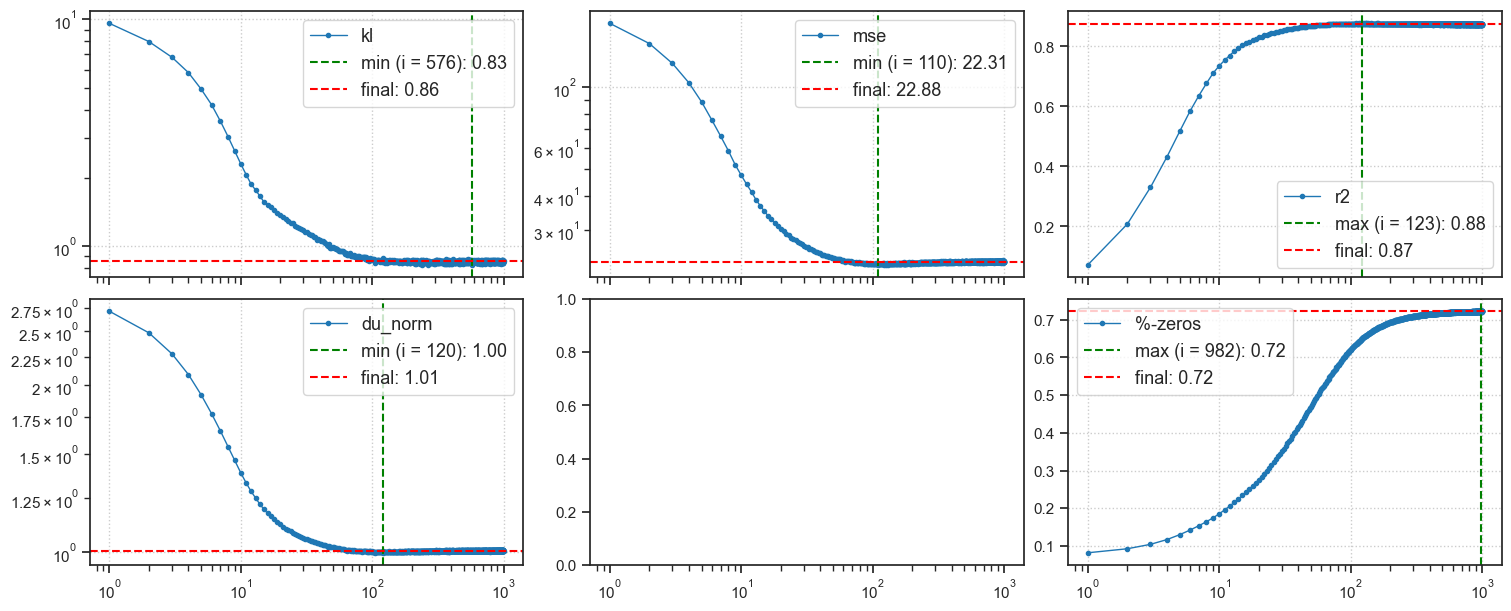

CPU times: user 25.9 s, sys: 112 ms, total: 26 s
Wall time: 26 s


In [10]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=10,
    compute_sprs=False,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='C0')

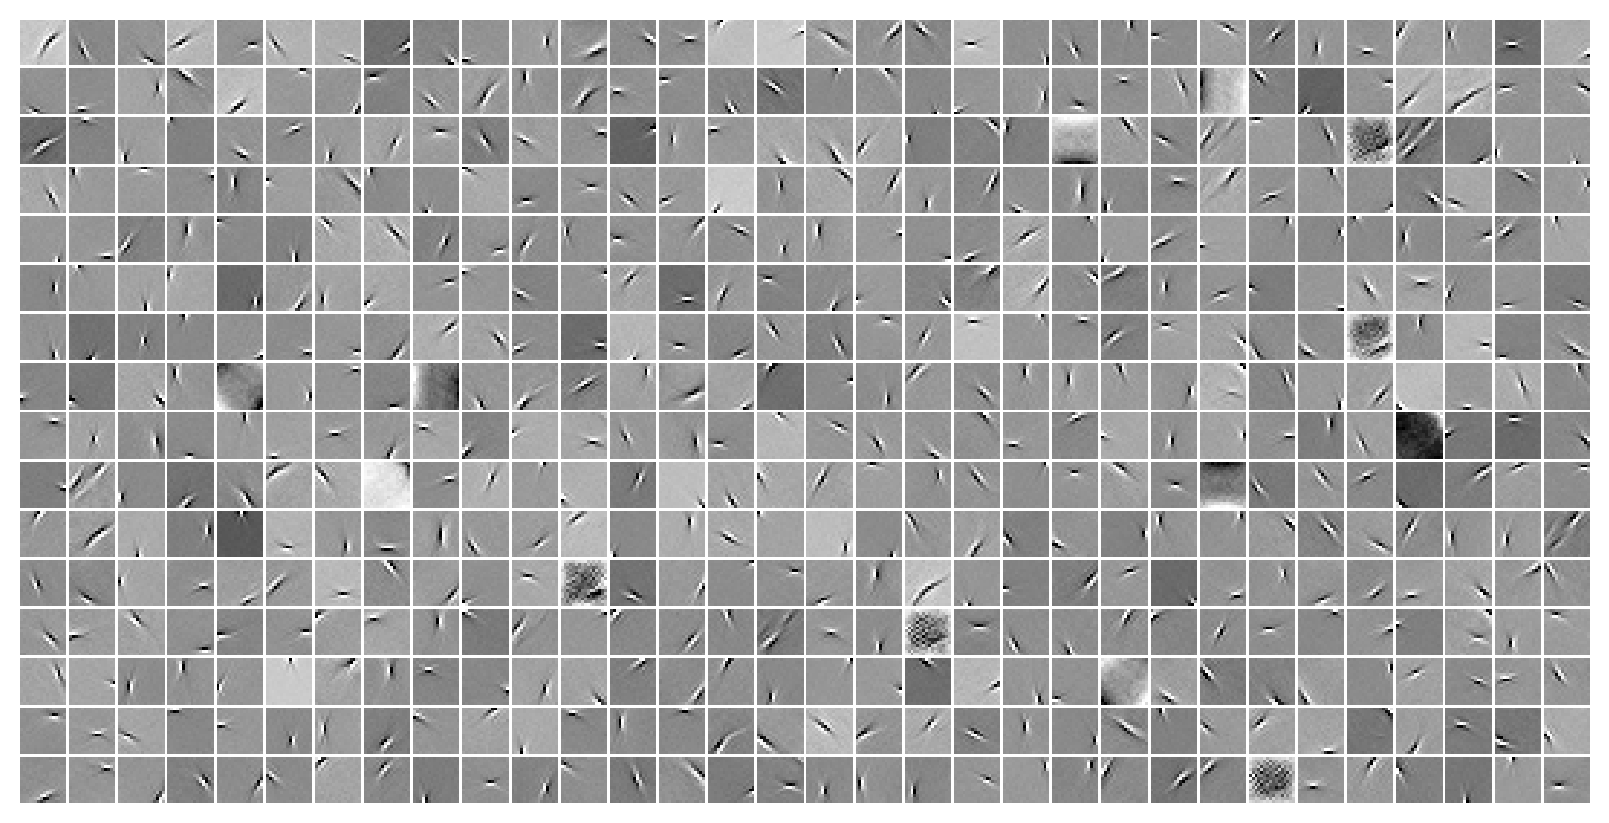

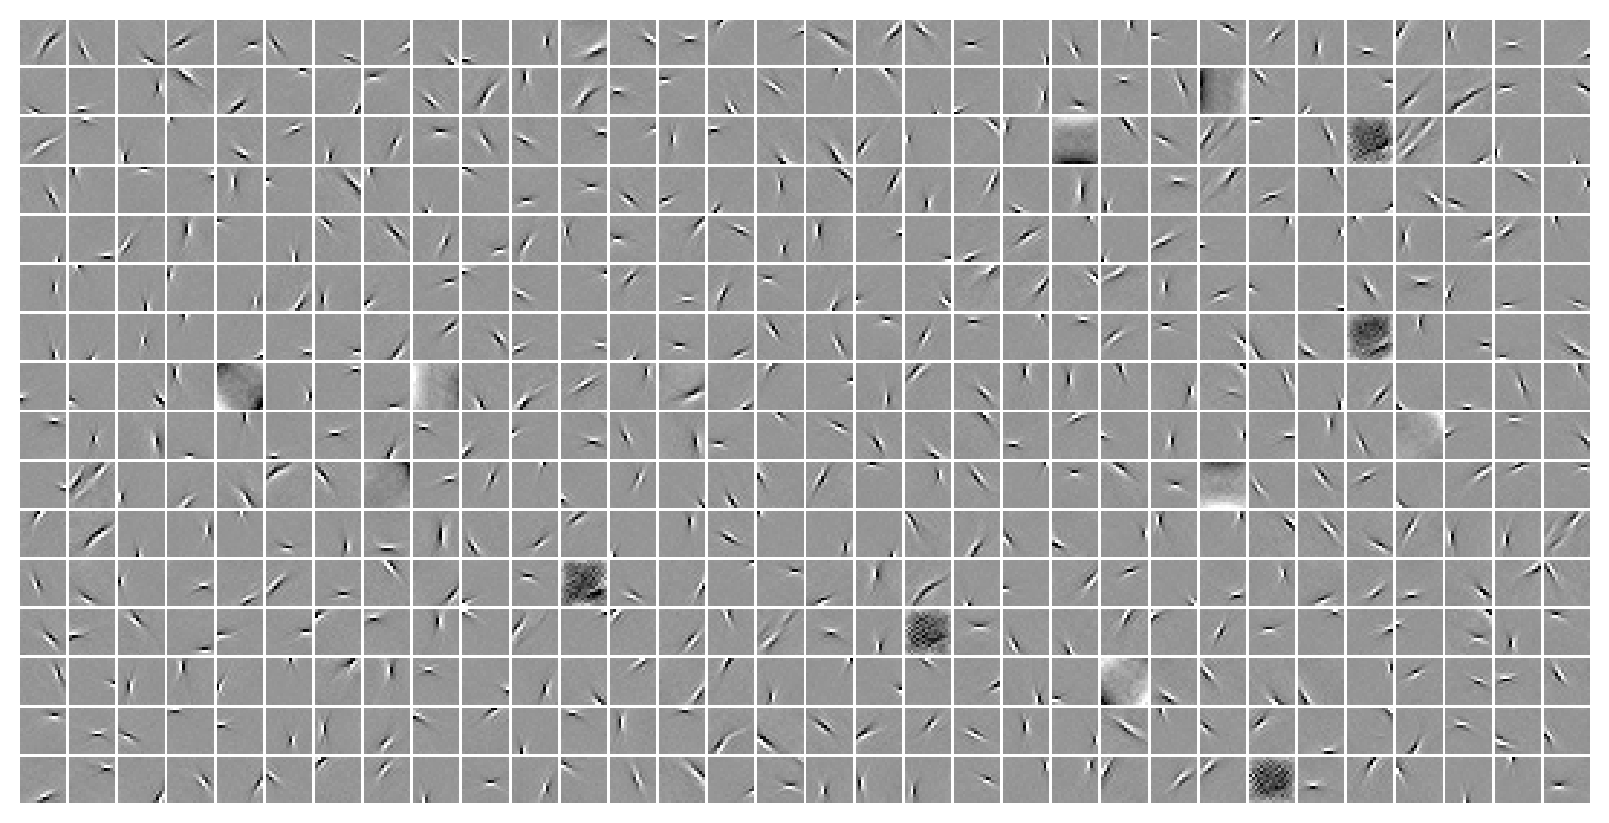

In [11]:
tr.model.show();
tr.model.show(method='abs-max');

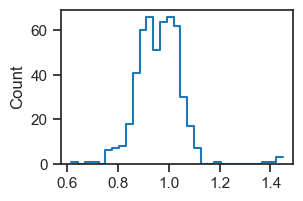

In [12]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
histplot(u0)
plt.show()